In [5]:
import pandas as pd

In [6]:
orders = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_orders_dataset.csv')
order_items  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_order_items_dataset.csv')
products  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_products_dataset.csv')
product_category_name_translation  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\product_category_name_translation.csv')

In [7]:
orders['order_purchase_timestamp'].head(10)

0    02/10/2017 10:56
1    24/07/2018 20:41
2    08/08/2018 08:38
3    18/11/2017 19:28
4    13/02/2018 21:18
5    09/07/2017 21:57
6    11/04/2017 12:22
7    16/05/2017 13:10
8    23/01/2017 18:29
9    29/07/2017 11:55
Name: order_purchase_timestamp, dtype: str

In [8]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce', format='%d/%m/%Y %H:%M')

print(orders[timestamp_cols].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [9]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], format='%d/%m/%Y %H:%M')

In [10]:
order_items['shipping_limit_date'] 

0        2017-09-19 09:45:00
1        2017-05-03 11:05:00
2        2018-01-18 14:48:00
3        2018-08-15 10:10:00
4        2017-02-13 13:57:00
                 ...        
112645   2018-05-02 04:11:00
112646   2018-07-20 04:31:00
112647   2017-10-30 17:14:00
112648   2017-08-21 00:04:00
112649   2018-06-12 17:10:00
Name: shipping_limit_date, Length: 112650, dtype: datetime64[us]

In [11]:
# Example: Turns '$1,200.50' into '1200.50'
order_items[' price '] = order_items[' price '].str.replace('$', '').str.replace(',', '')

# Safely convert to float, turning any leftover bad text into a blank space (NaN)
order_items[' price '] = pd.to_numeric(order_items[' price '], errors='coerce')


In [12]:
revenue_cols = [' price ', 'freight_value']

for cols in revenue_cols:
    order_items[cols] = pd.to_numeric(order_items[cols], errors='coerce').fillna(0).astype(float)

print(order_items[revenue_cols].dtypes)


 price           float64
freight_value    float64
dtype: object


In [13]:
merged = orders.merge(order_items, on='order_id')
merged = merged.merge(products, on='product_id')
merged = merged.merge(product_category_name_translation, on='product_category_name')

In [14]:
merged.info

<bound method DataFrame.info of                                 order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
111018  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
111019  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
111020  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
111021  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
111022  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purch

In [15]:
merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [16]:
merged.shape

(111023, 23)

In [17]:
delivered = merged[merged['order_status'] == 'delivered']

In [18]:
delivered

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:00,2018-02-06 13:10:00,2018-02-07 23:22:00,2018-02-28 17:37:00,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,baby
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:00,2017-08-27 15:04:00,2017-08-28 20:52:00,2017-09-21 11:24:00,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories


In [19]:
category_revenue = delivered.groupby('product_category_name_english')[' price '].sum() + delivered.groupby('product_category_name_english')['freight_value'].sum()

In [20]:
category_revenue

product_category_name_english
agro_industry_and_commerce      76203.30
air_conditioning                59854.55
art                             27485.53
arts_and_craftmanship            2184.14
audio                           56255.32
                                 ...    
stationery                     269575.05
tablets_printing_image           8754.61
telephony                      379202.62
toys                           547061.06
watches_gifts                 1264333.12
Length: 71, dtype: float64

In [29]:
category_revenue.sort_values(ascending=False).head(10)

product_category_name_english
health_beauty            1412089.53
watches_gifts            1264333.12
bed_bath_table           1225209.26
sports_leisure           1118256.91
computers_accessories    1032723.77
furniture_decor           880329.92
housewares                758392.25
cool_stuff                691680.89
auto                      669454.75
garden_tools              567145.68
dtype: float64

# Matplotlib Visualization

In [31]:
import matplotlib.pyplot as plt

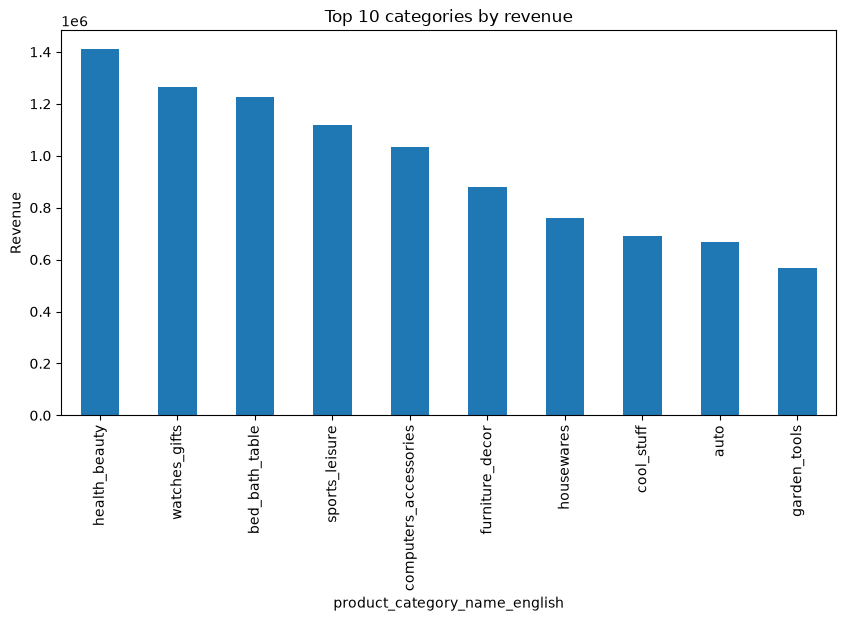

In [36]:
category_revenue.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 categories by revenue')
plt.ylabel('Revenue')
plt.show()